# *ENERGY_CONSUMPTION DATA SET*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


In [3]:
# import the dataset

data = pd.read_csv("Energy_Consumption.csv") 

In [4]:
# Display summary

data.describe()

,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption
count,1006.000000,1003.000000,1007.000000,1007.000000,1003.000000,1007.000000
mean,24.981495,45.318506,1500.042440,4.568024,15.158549,77.061361
std,2.836123,8.547262,288.365510,2.867708,8.728922,8.152197
min,20.007565,30.015975,1000.512661,0.000000,0.006642,53.263278
25%,22.642092,38.134328,1246.278670,2.000000,7.657581,71.547208
50%,24.751637,45.794528,1508.016302,5.000000,15.106151,76.950389
75%,27.418523,52.393862,1740.468773,7.000000,22.886587,82.933014
max,29.998671,59.969085,1999.982252,9.000000,29.965327,99.201120


## Perform the following Analysis on the dataset in different blocks:

In [5]:
#  Check for column names

data.columns

Index(['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy',
       'HVACUsage', 'LightingUsage', 'RenewableEnergy', 'DayOfWeek', 'Holiday',
       'EnergyConsumption'],
      dtype='object')

In [6]:
# Display top 10 rows

data.head(10)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,01/01/2022 00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373
1,01/01/2022 01:00,27.731651,54.225919,1411.064918,1,On,On,21.831384,Saturday,No,83.401855
2,01/01/2022 02:00,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,Sunday,No,78.270888
3,01/01/2022 03:00,20.080469,50.371637,1452.316318,1,Off,On,8.623447,Wednesday,No,56.519850
4,01/01/2022 04:00,23.097359,51.401421,1094.130359,9,On,Off,3.071969,Friday,No,70.811732
5,01/01/2022 05:00,29.576037,36.824263,1871.709180,6,Off,Off,17.626690,Sunday,Yes,84.321885
6,01/01/2022 06:00,25.131167,35.709622,1607.001228,6,On,Off,24.264702,Friday,Yes,76.165791
7,01/01/2022 07:00,23.182844,31.679920,1633.955330,8,Off,Off,27.517099,Thursday,Yes,74.131906
8,01/01/2022 08:00,25.391999,46.399364,1240.309224,6,On,Off,2.307595,Sunday,No,78.206236
9,01/01/2022 09:00,22.212549,32.418464,1705.420336,1,On,Off,29.140071,Tuesday,No,77.992214


In [7]:
# Display basic information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1007 non-null   object 
 1   Temperature        1006 non-null   float64
 2   Humidity           1003 non-null   float64
 3   SquareFootage      1007 non-null   float64
 4   Occupancy          1007 non-null   int64  
 5   HVACUsage          1007 non-null   object 
 6   LightingUsage      1007 non-null   object 
 7   RenewableEnergy    1003 non-null   float64
 8   DayOfWeek          1007 non-null   object 
 9   Holiday            1007 non-null   object 
 10  EnergyConsumption  1007 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.7+ KB


## *Visualization: Energy Consumption and Renewable Energy vs Timestamp*

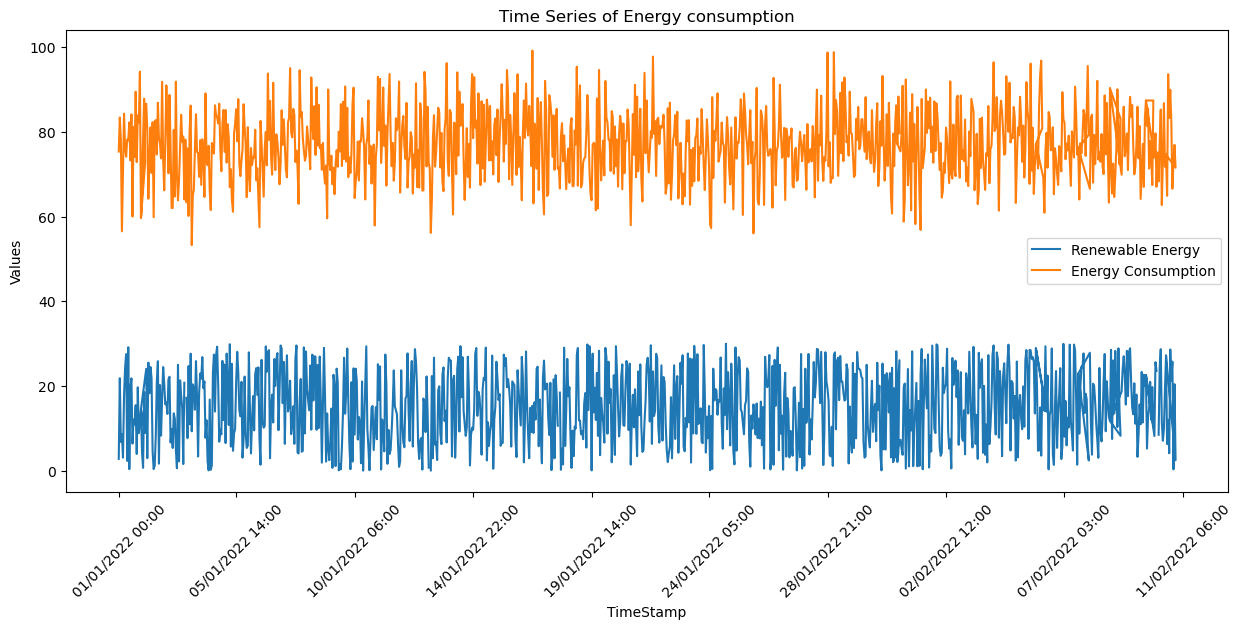

In [8]:
plt.figure(figsize=(15, 6))

# Adjust this number based on how many timestamps you want
 
num_ticks = 10  
tick_indices = np.linspace(0, len(data['Timestamp']) - 1, num_ticks, dtype=int)
tick_labels = [data['Timestamp'][i] for i in tick_indices]
 
plt.xticks(tick_indices, tick_labels, rotation=45)
 
plt.plot(data['Timestamp'], data['RenewableEnergy'], label='Renewable Energy')
plt.plot(data['Timestamp'], data['EnergyConsumption'], label='Energy Consumption')

plt.xlabel('TimeStamp')
plt.ylabel('Values')

plt.title('Time Series of Energy consumption')

# Rotate labels by 45 degrees

plt.xticks(rotation=45)  
plt.legend()
plt.show()

## *Using the sample code from class, display all the data points with missing values*

In [9]:
# Display all rows with missing values

data[data.isnull().any(axis=1)]

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
20,01/01/2022 20:00,NaN,59.931895,1211.261802,9,On,On,11.703978,Friday,Yes,94.236288
51,03/01/2022 02:00,21.754026,NaN,1514.827037,4,Off,Off,9.846127,Tuesday,No,62.055055
64,03/01/2022 15:00,25.382745,51.902700,1350.756585,0,Off,Off,NaN,Tuesday,No,78.187281
120,05/01/2022 23:00,27.308422,NaN,1239.620280,8,Off,On,22.210965,Monday,Yes,81.190938
282,12/01/2022 17:00,29.248673,NaN,1025.039867,4,On,Off,25.683314,Thursday,Yes,91.490982
295,13/01/2022 06:00,21.841437,57.528479,1214.575550,1,Off,Off,NaN,Sunday,Yes,71.369356
403,17/01/2022 18:00,22.234646,NaN,1855.502668,3,Off,Off,25.987465,Wednesday,Yes,60.541460
417,18/01/2022 08:00,20.572217,43.972162,1828.686036,5,On,On,NaN,Tuesday,No,71.594942
988,10/02/2022 22:00,24.643517,35.280929,1728.931522,5,Off,On,NaN,Sunday,No,75.146012


In [10]:
# Drop rows with any missing values

data_cleaned = data.dropna()

In [11]:
# Fill missing values with the mean of the respective columns

data['Temperature'] = data['Temperature'].fillna(data['Temperature'].mean())

data['Humidity'] = data['Humidity'].fillna(data['Humidity'].mean())

data['RenewableEnergy'] = data['RenewableEnergy'].fillna(data['RenewableEnergy'].mean())

In [12]:
# Display duplicate rows

data[data.duplicated()]

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
26,01/01/2022 21:00,21.101112,30.418006,1677.105261,3,Off,Off,14.517204,Sunday,Yes,59.672380
740,31/01/2022 12:00,24.258571,32.210803,1210.199640,1,On,Off,2.057832,Monday,Yes,79.536413
876,06/02/2022 03:00,24.981070,40.597123,1774.370614,1,Off,Off,28.872775,Tuesday,No,77.120780
921,07/02/2022 19:00,27.475827,36.330662,1013.072714,1,On,Off,22.891634,Wednesday,No,76.260715
952,09/02/2022 01:00,29.607943,53.482526,1458.125785,0,On,Off,11.733416,Wednesday,No,90.279794
984,10/02/2022 11:00,28.018439,31.607004,1848.972478,7,Off,Off,22.589281,Friday,No,87.408310
1006,11/02/2022 06:00,22.619671,33.826955,1508.402565,6,On,On,27.152599,Wednesday,No,74.638956


In [13]:
# Drop duplicate rows

data_no_duplicates = data.drop_duplicates()

In [14]:
# Initialize LabelEncoder

encoder = LabelEncoder()

# Apply LabelEncoder to the columns

data['HVACUsage'] = encoder.fit_transform(data['HVACUsage'])
data['LightingUsage'] = encoder.fit_transform(data['LightingUsage'])
data['Holiday'] = encoder.fit_transform(data['Holiday'])

In [15]:
# droppiung columns HVACUsage, LightingUsage, Holiday columns and renaming encoding columns to intial names

data.drop(columns=['HVACUsage', 'LightingUsage', 'Holiday'], inplace=True)
data.rename(columns={'HVACUsage_Encoded': 'HVACUsage'}, inplace=True)
data.rename(columns={'LightingUsage_Encoded': 'LightingUsage'}, inplace=True)
data.rename(columns={'Holiday_Encoded': 'Holiday'}, inplace=True)

In [16]:
# One-hot encode the 'DayOfWeek' column

data['DayOfWeek_duplicate'] = data[["DayOfWeek"]]
data = pd.get_dummies(data, columns=["DayOfWeek_duplicate"], prefix='Day_Of_Week')

data.loc[:, 'DayOfWeek_Encoded'] = encoder.fit_transform(data['DayOfWeek'])
data.drop(columns=['DayOfWeek'], inplace=True)
data.rename(columns={'DayOfWeek_Encoded': 'DayOfWeek'}, inplace=True)

### 5. Perform the following Analysis on the dataset in different blocks:

In [17]:
data.head()

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption,Day_Of_Week_Friday,Day_Of_Week_Monday,Day_Of_Week_Saturday,Day_Of_Week_Sunday,Day_Of_Week_Thursday,Day_Of_Week_Tuesday,Day_Of_Week_Wednesday,DayOfWeek
0,01/01/2022 00:00,25.139433,43.431581,1565.693999,5,2.774699,75.364373,False,True,False,False,False,False,False,1
1,01/01/2022 01:00,27.731651,54.225919,1411.064918,1,21.831384,83.401855,False,False,True,False,False,False,False,2
2,01/01/2022 02:00,28.704277,58.907658,1755.715009,2,6.764672,78.270888,False,False,False,True,False,False,False,3
3,01/01/2022 03:00,20.080469,50.371637,1452.316318,1,8.623447,56.519850,False,False,False,False,False,False,True,6
4,01/01/2022 04:00,23.097359,51.401421,1094.130359,9,3.071969,70.811732,True,False,False,False,False,False,False,0


In [18]:
# Display summary

print(data.describe())

# Check for column names

print(data.columns)

# Display the top 10 rows

print(data.head(10))

# Display basic information

print(data.info())

       Temperature     Humidity  SquareFootage    Occupancy  RenewableEnergy  \
count  1007.000000  1007.000000    1007.000000  1007.000000      1007.000000   
mean     24.981495    45.318506    1500.042440     4.568024        15.158549   
std       2.834713     8.530253     288.365510     2.867708         8.711551   
min      20.007565    30.015975    1000.512661     0.000000         0.006642   
25%      22.643581    38.183217    1246.278670     2.000000         7.683173   
50%      24.754216    45.783122    1508.016302     5.000000        15.140346   
75%      27.418348    52.359844    1740.468773     7.000000        22.853482   
max      29.998671    59.969085    1999.982252     9.000000        29.965327   

       EnergyConsumption    DayOfWeek  
count        1007.000000  1007.000000  
mean           77.061361     2.935452  
std             8.152197     1.993230  
min            53.263278     0.000000  
25%            71.547208     1.000000  
50%            76.950389     3.000000  

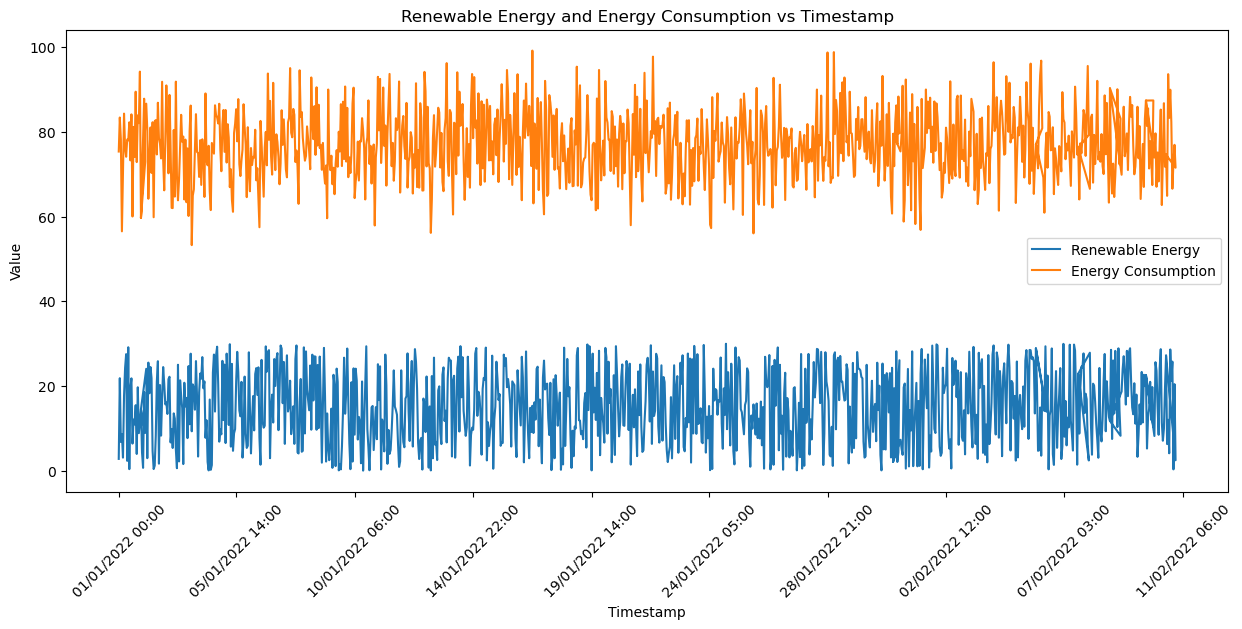

In [19]:
# Visualization (Energy Consumption vs Renewable Energy)

plt.figure(figsize=(15, 6))

# Adjust this number based on how many timestamps you want
 
num_ticks = 10  
tick_indices = np.linspace(0, len(data['Timestamp']) - 1, num_ticks, dtype=int)
tick_labels = [data['Timestamp'][i] for i in tick_indices]
 
plt.xticks(tick_indices, tick_labels, rotation=45)


plt.plot(data['Timestamp'], data['RenewableEnergy'], label='Renewable Energy')
plt.plot(data['Timestamp'], data['EnergyConsumption'], label='Energy Consumption')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Renewable Energy and Energy Consumption vs Timestamp')
plt.legend()
plt.show()

## *Split your dataset into X with the columns*
 - Timestamp 
 - Temperature
 - Humidity
 - SquareFootage 
 - Occupancy 
 - HVACUsage 
 - LightingUsage
 - RenewableEnergy 
 - DayOfWeek 
 - Holiday
 
 *Y with the column*
 - EnergyConsumption. 

In [20]:
# Split your dataset into X (features) and Y (target):

# Define X (features) and Y (target)

# Check if 'DayOfWeek' was one-hot encoded and now exists as multiple columns
data['Timestamp'] = pd.to_datetime(data['Timestamp'], format='%d/%m/%Y %H:%M')


if 'DayOfWeek' in data.columns:
    X = data[['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 
             'RenewableEnergy', 'DayOfWeek']]
else:
    # If 'DayOfWeek' has been one-hot encoded, select the one-hot encoded columns instead
    # These might be named like 'DayOfWeek_Monday', 'DayOfWeek_Tuesday', etc.
    
    day_of_week_columns = [col for col in data.columns if 'DayOfWeek' in col]
    X = data[['Timestamp', 'Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 
            'HVACUsage', 'LightingUsage', 'RenewableEnergy'] + day_of_week_columns + ['Holiday']]

# Define Y (target column)
Y = data['EnergyConsumption']


## *Normalize all the data in the X with the exception of the Timestamp column.*


In [21]:
# Drop the 'Timestamp' column

X_no_timestamp = X.drop(columns=['Timestamp'])
feature_names = X_no_timestamp.columns
# Apply MinMaxScaler to the remaining features

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_no_timestamp)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Timestamp              1007 non-null   datetime64[ns]
 1   Temperature            1007 non-null   float64       
 2   Humidity               1007 non-null   float64       
 3   SquareFootage          1007 non-null   float64       
 4   Occupancy              1007 non-null   int64         
 5   RenewableEnergy        1007 non-null   float64       
 6   EnergyConsumption      1007 non-null   float64       
 7   Day_Of_Week_Friday     1007 non-null   bool          
 8   Day_Of_Week_Monday     1007 non-null   bool          
 9   Day_Of_Week_Saturday   1007 non-null   bool          
 10  Day_Of_Week_Sunday     1007 non-null   bool          
 11  Day_Of_Week_Thursday   1007 non-null   bool          
 12  Day_Of_Week_Tuesday    1007 non-null   bool          
 13  Day

## *Perform feature selection using RandomForest Regressor to use only top 8 features from the X.*

In [23]:
# Initialize and fit the model

model = RandomForestRegressor()
model.fit(X_scaled, Y)

# Get feature importances

feature_importances = model.feature_importances_

# Sort features based on importance

sorted_features = sorted(zip(feature_names, feature_importances), key=lambda x: x[1])

# Print the sorted features

for feature, score in sorted_features:
    print(f"{feature}: {score}")


DayOfWeek: 0.04250950662341962
Occupancy: 0.0755174435140466
SquareFootage: 0.08960341642273104
Humidity: 0.0977812873432982
RenewableEnergy: 0.10155586852926748
Temperature: 0.5930324775672371


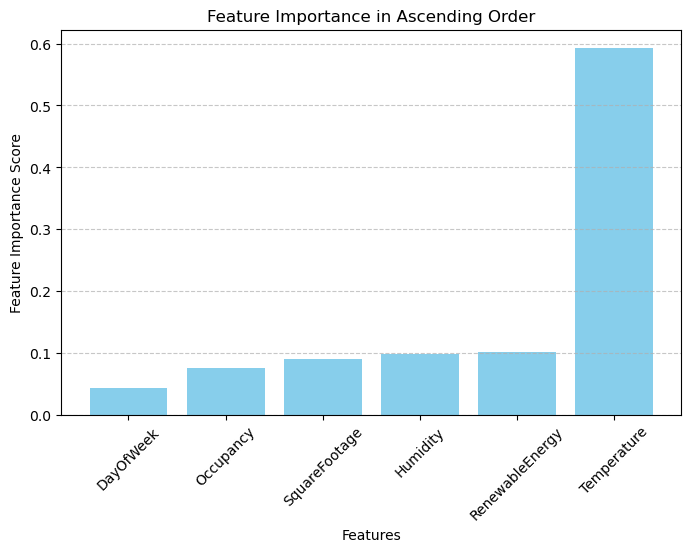

In [24]:
features, scores = zip(*sorted_features)  

# Plot bar graph

plt.figure(figsize=(8, 5))
plt.bar(features, scores, color='skyblue')  # Vertical bar chart
plt.xlabel("Features")
plt.ylabel("Feature Importance Score")
plt.title("Feature Importance in Ascending Order")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

## *Perform the following Analysis on the dataset in different blocks:*

In [25]:
# Display summary

print(data.describe())

# Check for column names

print(data.columns)

# Display the top 10 rows

print(data.head(10))

# Display basic information

print(data.info())

                           Timestamp  Temperature     Humidity  SquareFootage  \
count                           1007  1007.000000  1007.000000    1007.000000   
mean   2022-01-21 21:24:54.339622656    24.981495    45.318506    1500.042440   
min              2022-01-01 00:00:00    20.007565    30.015975    1000.512661   
25%              2022-01-11 10:30:00    22.643581    38.183217    1246.278670   
50%              2022-01-21 22:00:00    24.754216    45.783122    1508.016302   
75%              2022-02-01 08:30:00    27.418348    52.359844    1740.468773   
max              2022-02-11 15:00:00    29.998671    59.969085    1999.982252   
std                              NaN     2.834713     8.530253     288.365510   

         Occupancy  RenewableEnergy  EnergyConsumption    DayOfWeek  
count  1007.000000      1007.000000        1007.000000  1007.000000  
mean      4.568024        15.158549          77.061361     2.935452  
min       0.000000         0.006642          53.263278     0

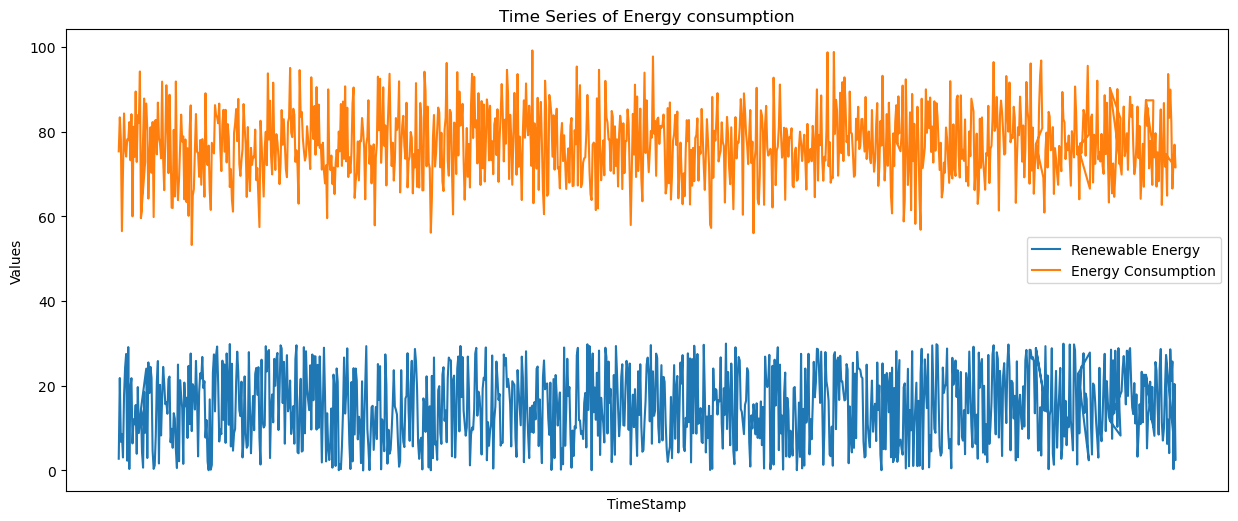

In [26]:
plt.figure(figsize=(15, 6))

num_ticks = 10  # Adjust this number based on how many timestamps you want
tick_indices = np.linspace(0, len(data['Timestamp']) - 1, num_ticks, dtype=int)
tick_labels = [data['Timestamp'][i] for i in tick_indices]

plt.xticks(tick_indices, tick_labels, rotation=45)

plt.plot(data['Timestamp'], data['RenewableEnergy'],label='Renewable Energy')
plt.plot(data['Timestamp'], data['EnergyConsumption'],label='Energy Consumption')
plt.xlabel('TimeStamp')
plt.ylabel('Values')
plt.title('Time Series of Energy consumption')
plt.xticks(rotation=45)  # Rotate labels by 45 degrees
plt.legend()
plt.show()

In [29]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Perform Time Series Split
n_splits = 5  # Adjust as needed
tscv = TimeSeriesSplit(n_splits=n_splits)

# Initialize the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Training & Evaluation
for train_index, test_index in tscv.split(X_scaled):
    x_train, x_test = x_scaled.iloc[train_index], x_scaled.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    rf.fit(X_train, y_train)

# Get feature importances
feature_importances = rf.feature_importances_

# Sort features based on importance
sorted_features = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# Print the sorted features
for feature, score in sorted_features:
    print(f"{feature}: {score}")


NameError: name 'x_scaled' is not defined